<a href="https://colab.research.google.com/github/ryurikritz/ProjectAIMLYear1May2026/blob/main/Easy_Visa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Easy Visa**

**Problem Statement**


Context
Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

Objective
In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

Data Description
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

case_id: ID of each visa application
continent: Information of continent the employee
education_of_employee: Information of education of the employee
has_job_experience: Does the employee has any job experience? Y= Yes; N = No
requires_job_training: Does the employee require any job training? Y = Yes; N = No
no_of_employees: Number of employees in the employer's company
yr_of_estab: Year in which the employer's company was established
region_of_employment: Information of foreign worker's intended region of employment in the US.
prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
case_status: Flag indicating if the Visa was certified or denied


In [32]:
# Write your code here to import necessary libraries for the project
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
print('XGBoost available:', HAS_XGB)

# Configure visual settings for cleaner notebook outputs
sns.set(style="whitegrid")                 # Sets a clean background style for future Seaborn plots
pd.set_option("display.max_columns", None) # Prevents Pandas from hiding columns in wide dataframes
plt.rcParams["figure.dpi"] = 110           # Increases the resolution of Matplotlib plots for readability

XGBoost available: True


**Understanding the structure of the data**

In [33]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# Write your code here to read the data
df = pd.read_csv('/content/drive/MyDrive/EasyVisa.csv')

In [35]:
# Write your code here to view the first 5 rows
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


**Finding rows and columns are present in the data**

In [36]:
# Write your code here
# Finding the rows and columns present in the dataset
rows = df.shape[0]
cols = df.shape[1]
print(f'There are {rows} rows and {cols} columns in the dataset.')

There are 25480 rows and 12 columns in the dataset.


**Finding the datatypes of the different columns in the dataset**

In [37]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Observations**

1. The dataset has 25,480 rows and 12 columns.
2. case_id is a unique identifier and carries no predictive value — it will be dropped.
3. There are 7 categorical and 4 numeric predictors plus the target.

**Are there any missing values in the data?**

In [38]:
# Write your code here
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


**Check the statistical summary of the data.**

In [39]:
# Write your code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


**Observations**

There are no missing values and no duplicate rows so the dataset is clean on these dimensions.

In [40]:
df = df.drop(columns=['case_id'])

**Observations**
We have dropped the identifier column.

In [41]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


In [42]:
df.describe(include='object').T

,count,unique,top,freq
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


**Observations of the Statistical Summary**

1. no_of_employees ranges from a negative minimum (impossible) up to ~602,000 — the negative values are clearly look to be a data-entry error and must be corrected.

2. The distribution is heavily right-skewed (mean ≈ 5,667 but median far lower).

3. yr_of_estab ranges from 1800 to 2016 — a few very old companies exist which means we can derive and understand company age from this field.

4. prevailing_wage spans from ~2 to ~319,210 with a mean of ~74,456. The very small values are tied to the Hourly wage unit, so wage is not directly comparable across units.

5. The target is imbalanced: ~66.8% Certified vs ~33.2% Denied (roughly 2:1)

# **Exploratory Data Analysis**

**Leading Questions for EDA**

What is the distribution of visa case statuses (certified vs. denied)? How does the education level of employees impact visa approval rates? Is there a significant difference in visa approval rates between employees with and without prior job experience? How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval? Do certain regions in the US have higher visa approval rates compared to others? How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate? Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

[IMPORTANT] **Beyond the Basics:** Please note that these are guiding questions only. To receive full points for this EDA section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

**Note**: Please note XGBoost can take a significantly longer time to run, so if you have time complexity issues then you can avoid building and tuning XGBoost. No marks will be deducted if the XGBoost model is not attempted.

**Target distribution**

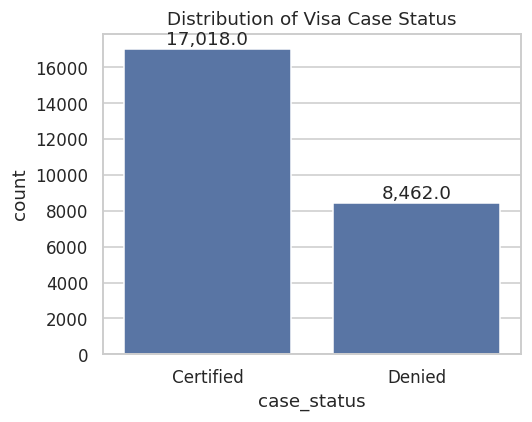

case_status
Certified   0.668
Denied      0.332
Name: proportion, dtype: float64


In [43]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='case_status', data=df, order=df['case_status'].value_counts().index)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of Visa Case Status'); plt.tight_layout(); plt.show()
print(df['case_status'].value_counts(normalize=True).round(3))

**Observation**: About two-thirds of applications are Certified. The class imbalance is moderate (2:1); This will get addressed later with over-/under-sampling and by using F1 as the metric.

**Univariate analysis — numeric features (each variable on its own)**

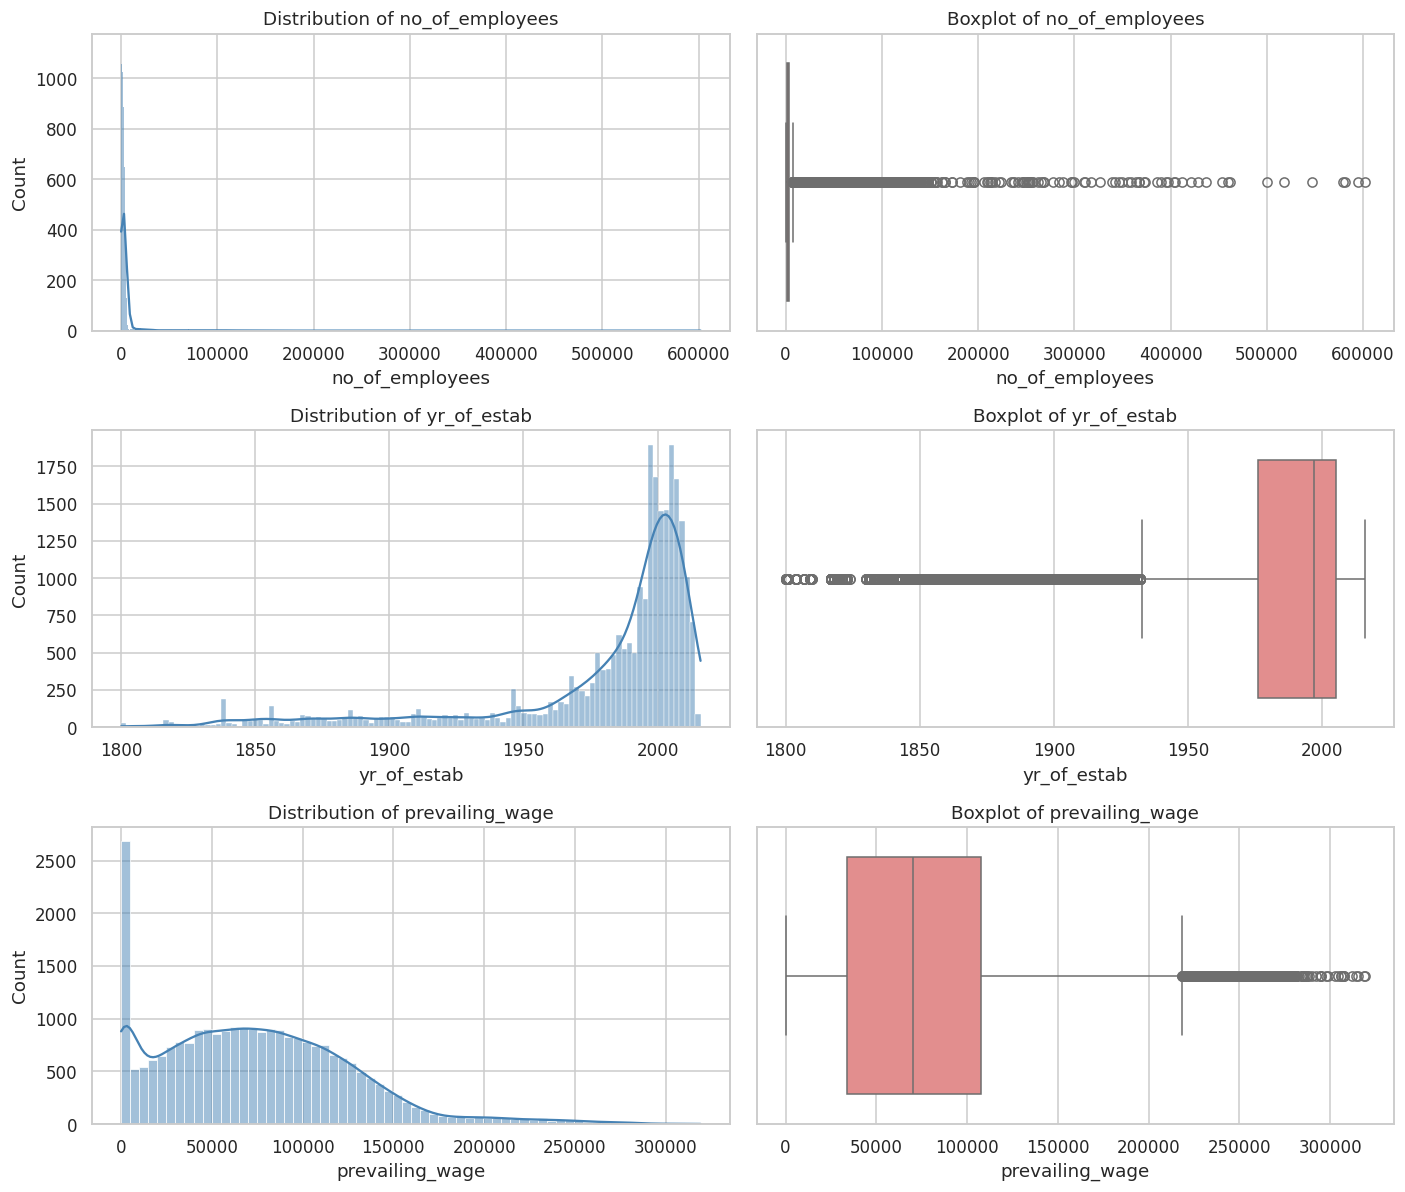

In [44]:
num_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for i, c in enumerate(num_cols):
    sns.histplot(df[c], kde=True, ax=axes[i,0], color='steelblue')
    axes[i,0].set_title(f'Distribution of {c}')
    sns.boxplot(x=df[c], ax=axes[i,1], color='lightcoral')
    axes[i,1].set_title(f'Boxplot of {c}')
plt.tight_layout(); plt.show()

**Observations on numeric univariate**

1. no_of_employees and prevailing_wage are strongly right-skewed with many high-end outliers, typical of firm-size and wage data.
2. no_of_employees contains impossible negative values (visible on the boxplot left tail).
3. yr_of_estab is left-skewed .Most employers were established after ~1980, with a long tail of older firms back to 1800.

**Univariate analysis — categorical features (each variable on its own)**

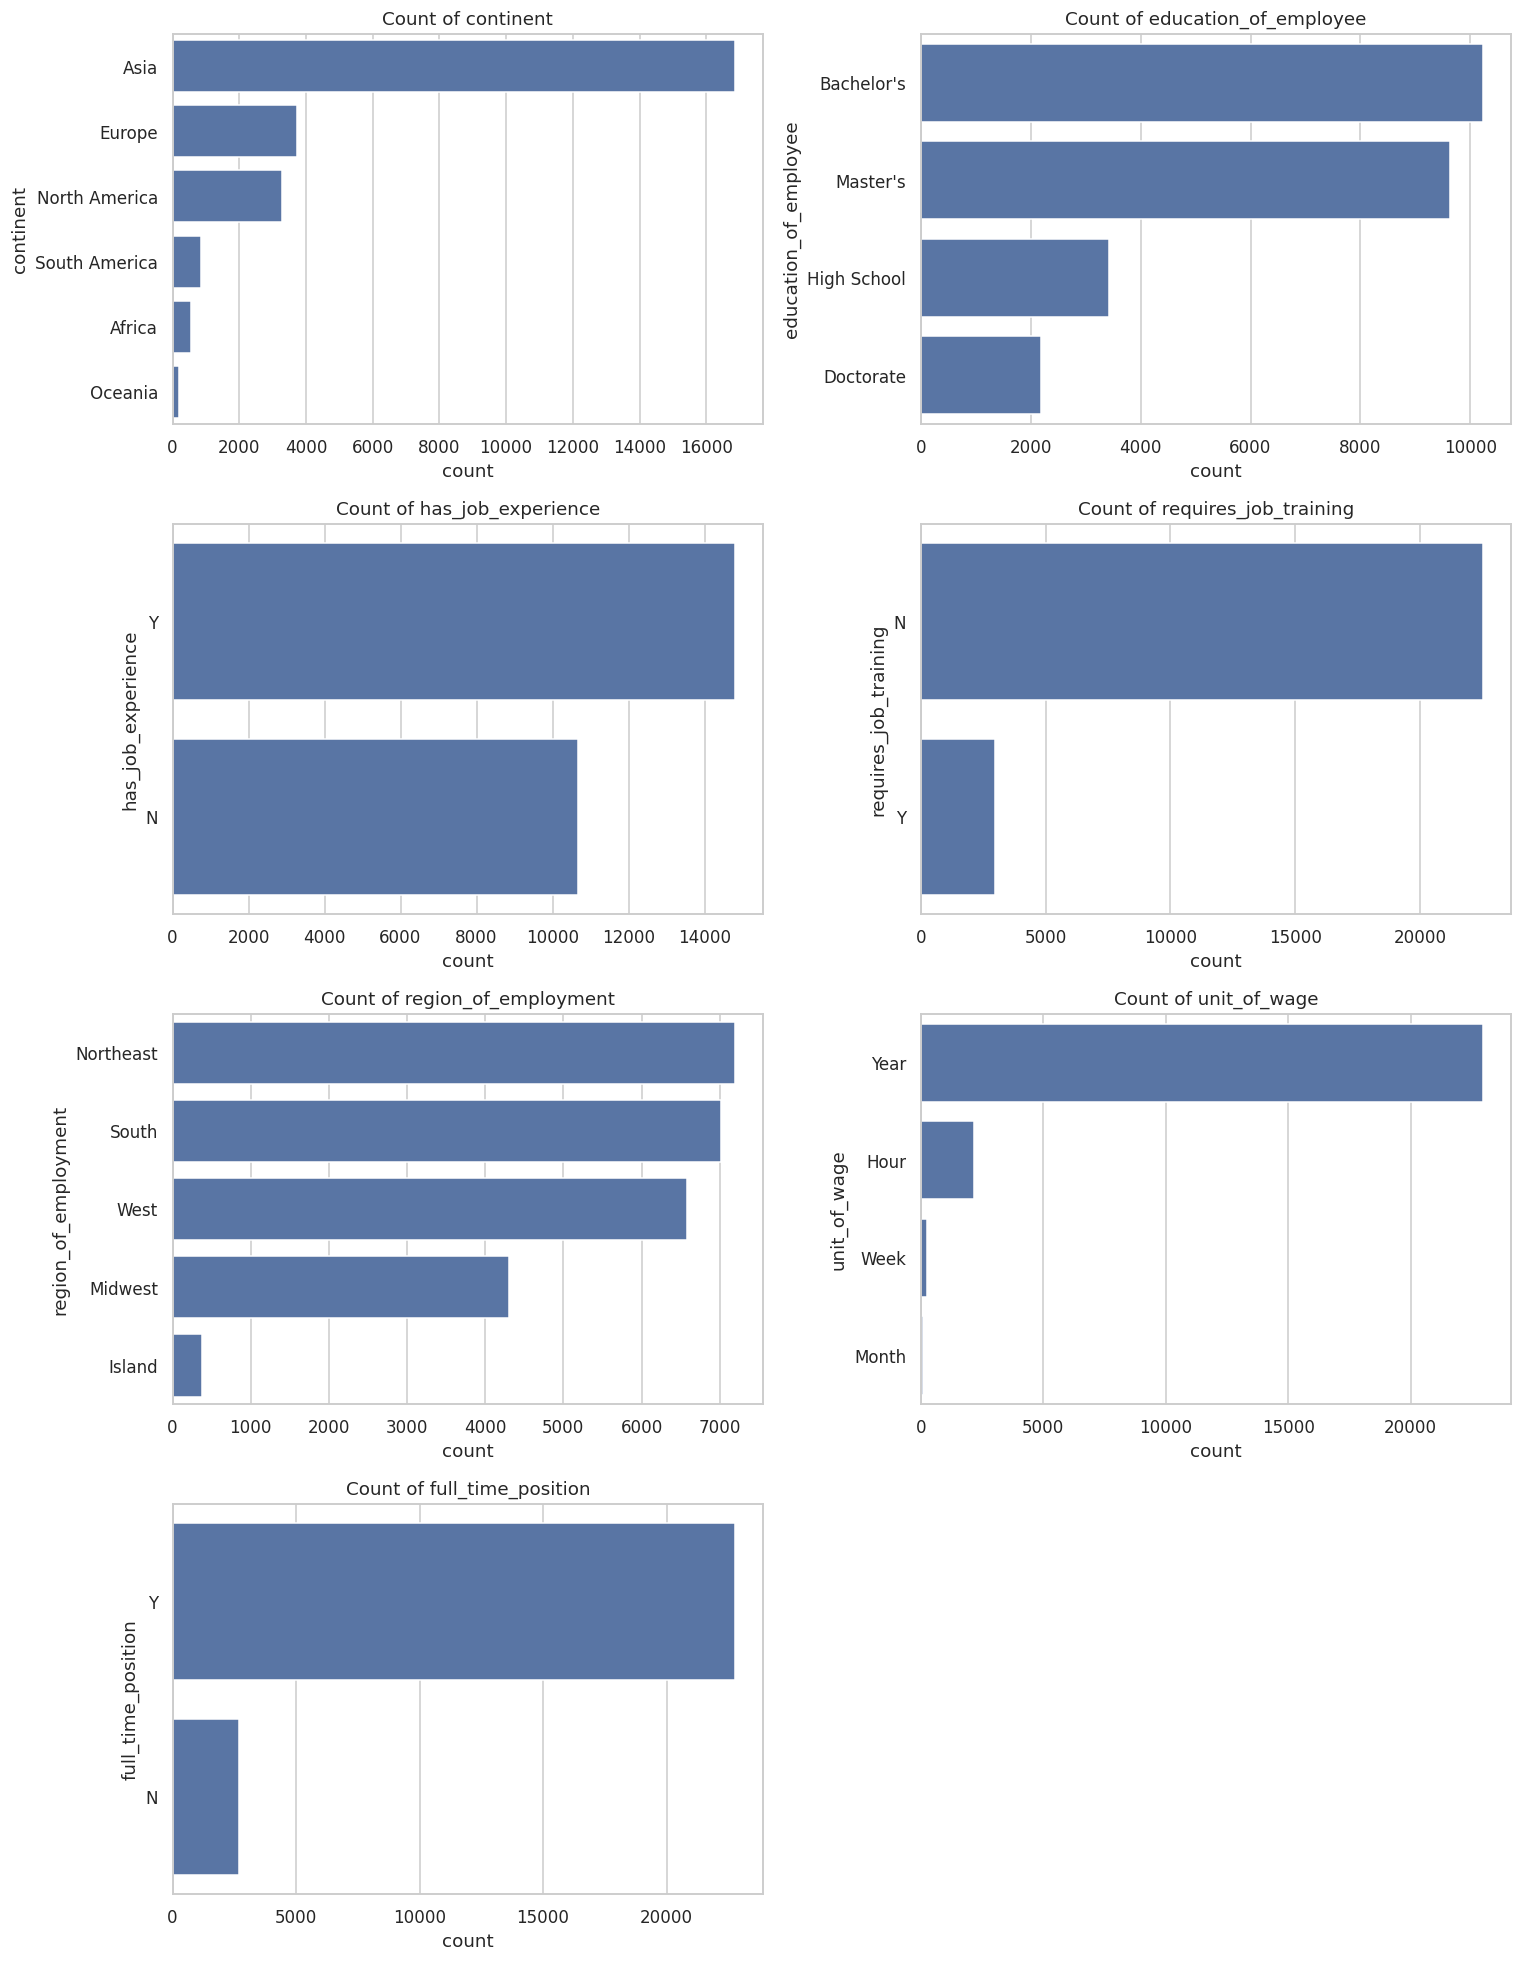

In [45]:
cat_cols = ['continent', 'education_of_employee', 'has_job_experience',
            'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position']
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, c in enumerate(cat_cols):
    order = df[c].value_counts().index
    sns.countplot(y=c, data=df, order=order, ax=axes[i])
    axes[i].set_title(f'Count of {c}')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

**Observations — Categorical univariate**

1. Continent: dominated by Asia (~66%); Oceania and Africa are rare.
2. Education: mostly Bachelor's and Master's; High School and Doctorate are smaller groups.
3. Job experience: ~58% of applicants have prior experience.
4. Job training: the vast majority (~88%) do not require training.
5. Region: Northeast, South and West dominate; Island is tiny.
6. Unit of wage: overwhelmingly Yearly (~90%); Hourly is the main alternative.
7. Full-time: ~89% of positions are full-time.

**Bivariate analysis (each variable vs the target)— Categorical drivers vs case status**

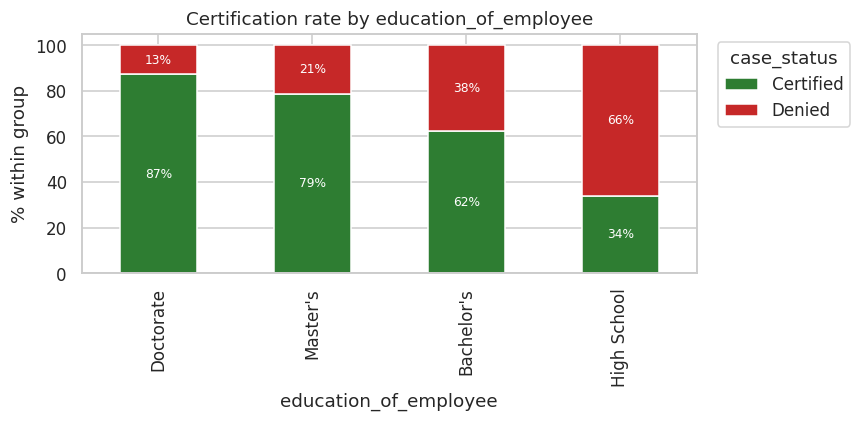

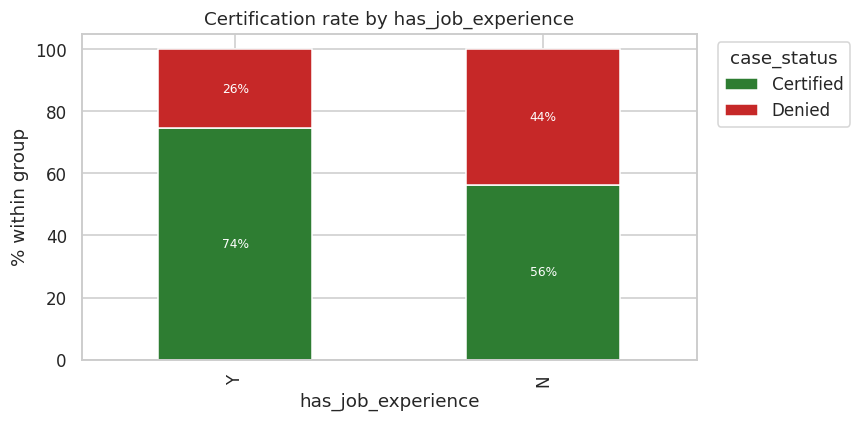

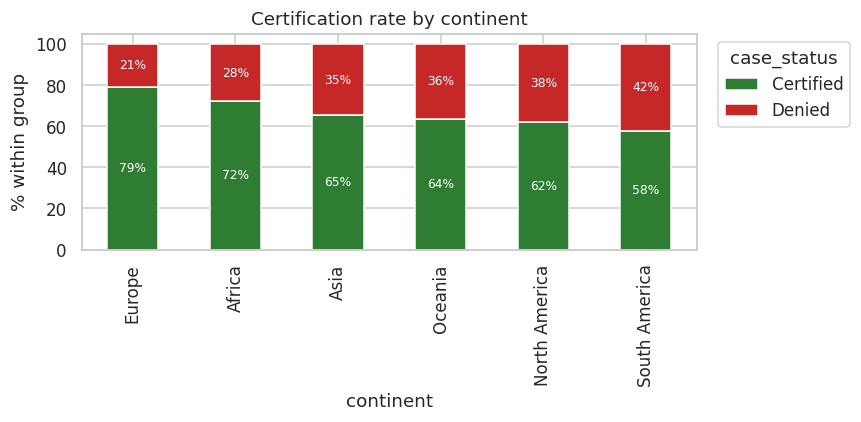

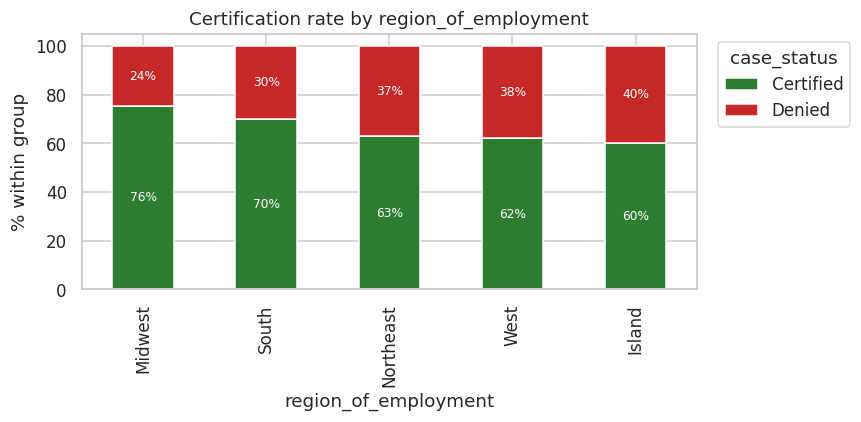

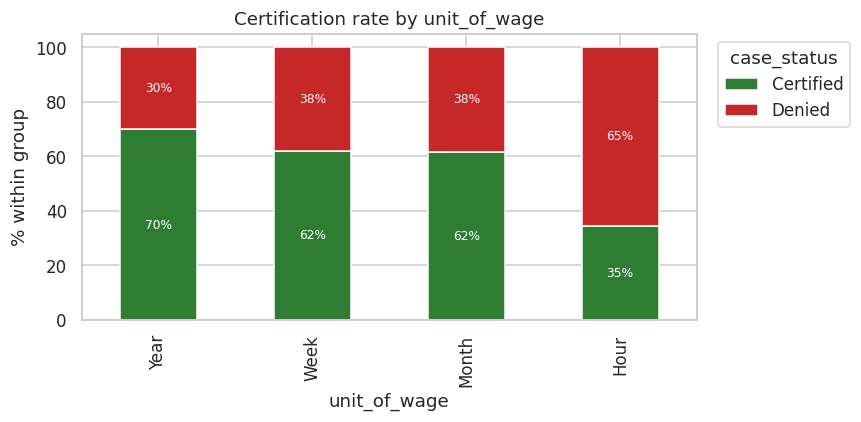

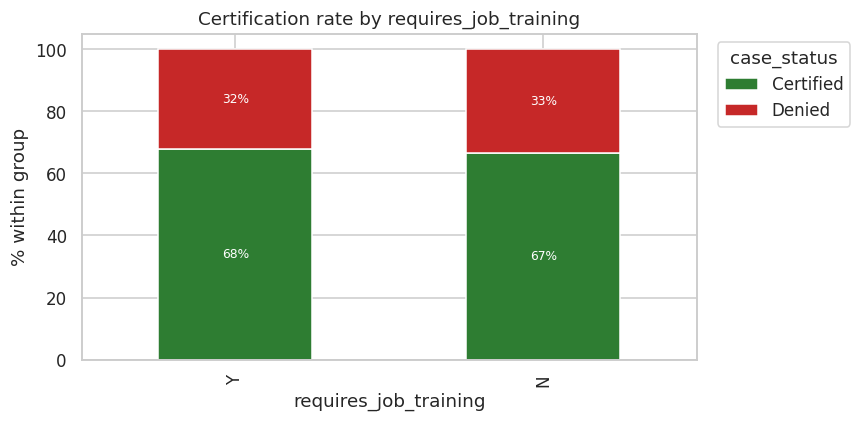

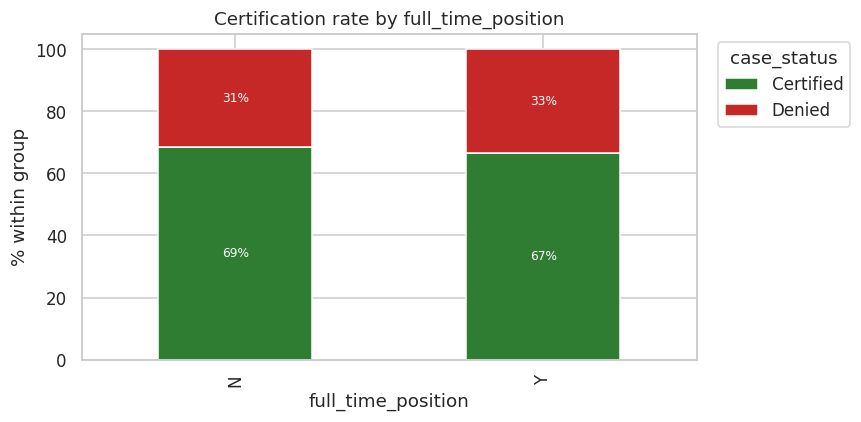

In [46]:
def stacked_rate(col):
    ct = pd.crosstab(df[col], df['case_status'], normalize='index')*100
    ct = ct.sort_values('Certified', ascending=False)
    ax = ct.plot(kind='bar', stacked=True, figsize=(8,4), color=['#2e7d32','#c62828'])
    plt.ylabel('% within group'); plt.title(f'Certification rate by {col}')
    plt.legend(title='case_status', bbox_to_anchor=(1.02,1), loc='upper left')
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=8)
    plt.tight_layout(); plt.show()

for col in ['education_of_employee','has_job_experience','continent',
            'region_of_employment','unit_of_wage','requires_job_training','full_time_position']:
    stacked_rate(col)

**Observations — categorical drivers (certification rate)**

1. Education is the single strongest driver: Doctorate 87% → Master's 79% → Bachelor's 62% → High School 34%. Higher education dramatically raises approval odds.

2. Job experience matters: applicants with experience are certified 74.5% of the time vs 56.1% without which is around ~18-point gap.
Continent: Europe (79%) and Africa (72%) approve highest; South America (58%) and North America (62%) lowest. Africa/Oceania are small samples.

3. Region: Midwest (76%) and South (70%) highest; Island (60%) and West (62%) lowest.

4. Unit of wage: Hourly workers are certified only 35% of the time vs ~70% for Yearly translating to a powerful signal (hourly pay proxies lower-skill roles).

5. Job training and full-time status show negligible differences which indicate they are likely weak predictors.

**Bivariate analysis (each variable vs the target) Numeric features vs case status**

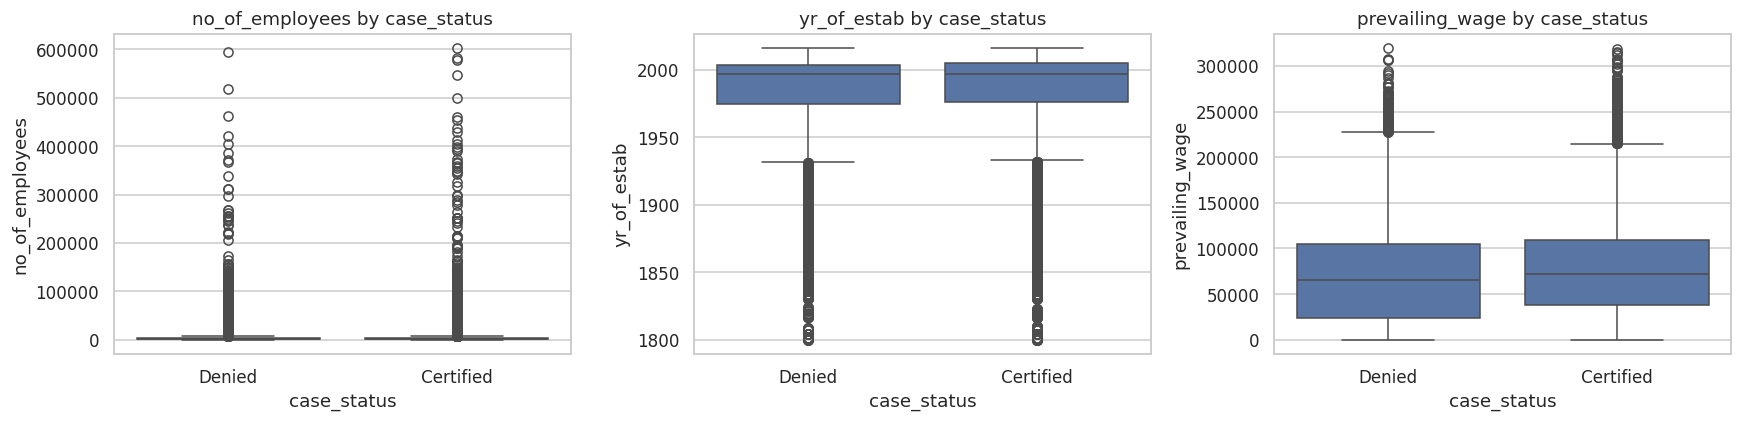

Median prevailing_wage (Yearly unit only) by status:
case_status
Certified   75428.000
Denied      77697.000
Name: prevailing_wage, dtype: float64


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for i, c in enumerate(num_cols):
    sns.boxplot(x='case_status', y=c, data=df, ax=axes[i])
    axes[i].set_title(f'{c} by case_status')
plt.tight_layout(); plt.show()

print('Median prevailing_wage (Yearly unit only) by status:')
print(df[df.unit_of_wage=='Year'].groupby('case_status')['prevailing_wage'].median().round(0))

**Observations — numeric vs target**

1. prevailing_wage alone barely separates the classes; medians for Certified vs Denied are close once we control for wage unit. Wage is informative mainly through its unit (hourly vs yearly), not its raw magnitude.
2. no_of_employees and yr_of_estab show little standalone separation so employer size and age are weak individual predictors of the outcome.

**Multivariate analysis**

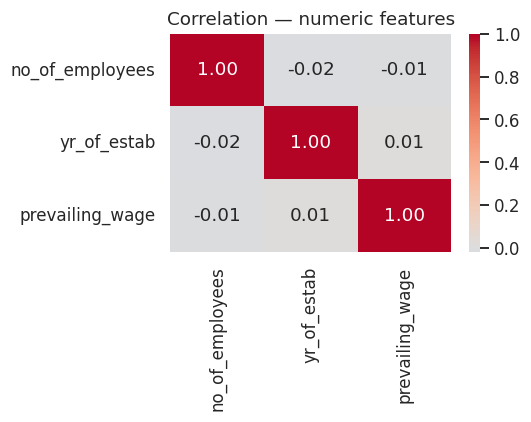

In [48]:
# Correlation among numeric features
plt.figure(figsize=(5,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation — numeric features'); plt.tight_layout(); plt.show()

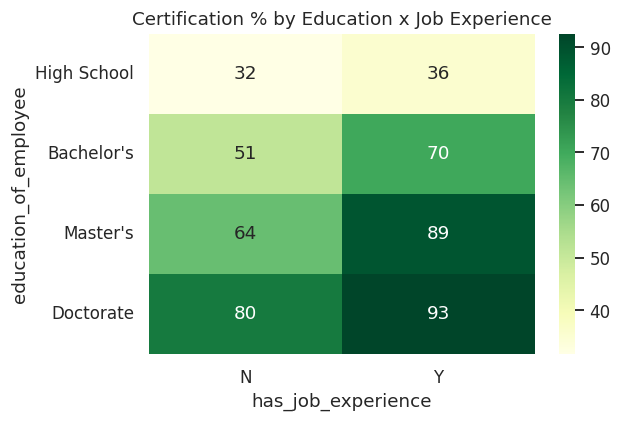

In [49]:
# Education x Job experience interaction on certification rate
piv = (df.assign(cert=(df.case_status=='Certified').astype(int))
         .pivot_table(index='education_of_employee', columns='has_job_experience',
                      values='cert', aggfunc='mean')*100)
piv = piv.reindex(['High School','Bachelor\'s','Master\'s','Doctorate'])
plt.figure(figsize=(6,4))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='YlGn')
plt.title('Certification % by Education x Job Experience'); plt.tight_layout(); plt.show()

**Observations — multivariate**

1. Numeric features are essentially uncorrelated with one another and there is no multicollinearity concern among them.
2. The Education × Experience heatmap shows the effects stack: a Doctorate with experience is the strongest profile, while High School without experience is the weakest. Experience adds the most lift at the lower education tiers.
3. Takeaway for modeling: the dominant signal lives in a handful of categorical features (education, wage unit, experience, continent, region), motivating tree-based ensemble models.

# **Data Pre-processing**

There are no missing values in the dataset so no imputation is required.

**Fixing invalid values in no_of_employees**

In [50]:
print('Negative no_of_employees before fix:', (df['no_of_employees'] < 0).sum())
# A company cannot have negative employees -> treat as data-entry sign error, take absolute value
df['no_of_employees'] = df['no_of_employees'].abs()
print('Negative after fix:', (df['no_of_employees'] < 0).sum())
print('New minimum:', df['no_of_employees'].min())

Negative no_of_employees before fix: 33
Negative after fix: 0
New minimum: 11


**Observations**: 33 records had negative employee counts, which is physically impossible. This is being treated as a sign error and taking the absolute value rather than dropping rows, preserving sample size.

**Feature engineering on company age**

In [51]:
# Data is from FY2016; derive company age and drop the raw year
df['company_age'] = 2016 - df['yr_of_estab']
df = df.drop(columns=['yr_of_estab'])
print(df['company_age'].describe().round(1))

count   25480.000
mean       36.600
std        42.400
min         0.000
25%        11.000
50%        19.000
75%        40.000
max       216.000
Name: company_age, dtype: float64


**Reasoning**: Absolute founding year is hard for a model to use directly; company age (reference year 2016) is a more meaningful feature.

**Outlier treatment**

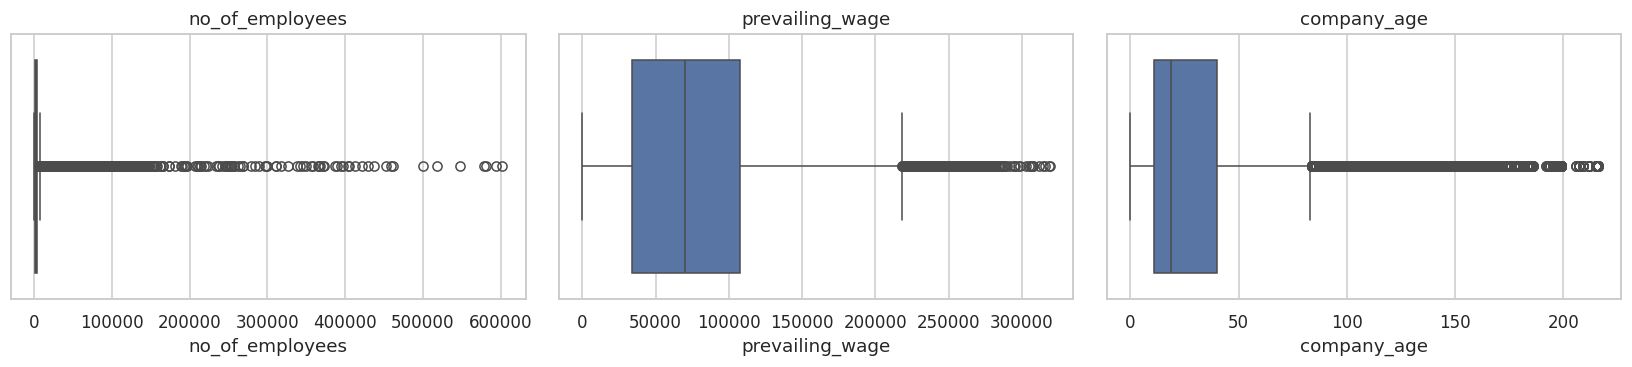

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15,3.5))
for i, c in enumerate(['no_of_employees','prevailing_wage','company_age']):
    sns.boxplot(x=df[c], ax=axes[i]); axes[i].set_title(c)
plt.tight_layout(); plt.show()

Observation -  There is a Decision in which there is no cap placed or  outliers removed. The extreme values in no_of_employees, prevailing_wage and company_age are genuine (large corporations, high-wage occupations, old firms), not errors. The final models are tree-based ensembles, which split on thresholds and are robust to outliers and monotonic scale so capping would discard real signal without benefit. Therefore keep the values as-is.

**Encoding & train/test split**

In [53]:
# Encode target: Certified = 1 (positive class), Denied = 0
data = df.copy()
data['case_status'] = (data['case_status'] == 'Certified').astype(int)

X = data.drop(columns=['case_status'])
y = data['case_status']

# One-hot encode categorical predictors
X = pd.get_dummies(X, drop_first=True)
print('Feature matrix shape after encoding:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train target balance:'); print(y_train.value_counts(normalize=True).round(3))

Feature matrix shape after encoding: (25480, 21)
Train: (17836, 21)  Test: (7644, 21)
Train target balance:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64


**Observations and Reasoning:** Categorical variables are one-hot encoded (drop_first=True to avoid the dummy trap). A 70/30 stratified split is being used so the 2:1 class ratio is preserved in both sets. Scaling is not applied because tree ensembles are scale-invariant.

# **Model Building**

We are building a tree-based classifiers on three versions of the training data — original, SMOTE oversampled, and random undersampled to evaluate on the untouched test set. A helper function records Accuracy, Recall, Precision and F1 for every model.

In [54]:
def get_metrics(model, X_tr, y_tr, X_te, y_te):
    tr_pred = model.predict(X_tr); te_pred = model.predict(X_te)
    return {
        'Train_Acc': accuracy_score(y_tr, tr_pred),
        'Test_Acc':  accuracy_score(y_te, te_pred),
        'Test_Recall': recall_score(y_te, te_pred),
        'Test_Precision': precision_score(y_te, te_pred),
        'Test_F1': f1_score(y_te, te_pred),
    }

def build_models(X_tr, y_tr, tag):
    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Bagging': BaggingClassifier(random_state=42, n_jobs=-1),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBClassifier(random_state=42, eval_metric='logloss',
                                          use_label_encoder=False, n_jobs=-1, verbosity=0)
    rows = []
    for name, m in models.items():
        m.fit(X_tr, y_tr)
        r = get_metrics(m, X_tr, y_tr, X_test, y_test)
        r['Model'] = f'{name} ({tag})'
        rows.append(r)
    return pd.DataFrame(rows).set_index('Model')

**Models on original (imbalanced) data**

In [55]:
res_orig = build_models(X_train, y_train, 'orig')
res_orig.sort_values('Test_F1', ascending=False)

,Train_Acc,Test_Acc,Test_Recall,Test_Precision,Test_F1
Model,,,,,
Gradient Boosting (orig),0.759,0.744,0.871,0.774,0.820
AdaBoost (orig),0.740,0.730,0.883,0.755,0.814
XGBoost (orig),0.843,0.732,0.860,0.768,0.811
Random Forest (orig),1.000,0.721,0.839,0.765,0.801
Bagging (orig),0.984,0.692,0.773,0.768,0.770
Decision Tree (orig),1.000,0.649,0.735,0.738,0.736


**Observation**: On the original data, boosting and Random Forest lead on F1. Single Decision Trees overfit badly (train accuracy ~1.0, lower test F1). Recall on the Certified class is already high because Certified is the majority.

**Models on SMOTE-oversampled data**

In [56]:
sm = SMOTE(random_state=42)
X_over, y_over = sm.fit_resample(X_train, y_train)
print('After SMOTE:', X_over.shape, dict(y_over.value_counts()))
res_over = build_models(X_over, y_over, 'over')
res_over.sort_values('Test_F1', ascending=False)

After SMOTE: (23826, 21) {0: np.int64(11913), 1: np.int64(11913)}


,Train_Acc,Test_Acc,Test_Recall,Test_Precision,Test_F1
Model,,,,,
Gradient Boosting (over),0.795,0.740,0.851,0.780,0.814
AdaBoost (over),0.780,0.732,0.852,0.771,0.809
XGBoost (over),0.861,0.727,0.844,0.770,0.805
Random Forest (over),1.000,0.716,0.815,0.772,0.793
Bagging (over),0.986,0.687,0.751,0.773,0.762
Decision Tree (over),1.000,0.645,0.719,0.742,0.730


**Observation**: Oversampling balances the training classes (50/50). This typically raises recall on the minority Denied class at a small cost to overall F1 on the Certified positive class. This is especially useful if the business wants to catch more likely-denials.

**Models on random-undersampled data**

In [57]:
us = RandomUnderSampler(random_state=42)
X_under, y_under = us.fit_resample(X_train, y_train)
print('After undersampling:', X_under.shape, dict(y_under.value_counts()))
res_under = build_models(X_under, y_under, 'under')
res_under.sort_values('Test_F1', ascending=False)

After undersampling: (11846, 21) {0: np.int64(5923), 1: np.int64(5923)}


,Train_Acc,Test_Acc,Test_Recall,Test_Precision,Test_F1
Model,,,,,
Gradient Boosting (under),0.723,0.704,0.721,0.815,0.765
AdaBoost (under),0.694,0.698,0.725,0.803,0.762
XGBoost (under),0.855,0.683,0.685,0.811,0.743
Random Forest (under),1.000,0.679,0.681,0.809,0.739
Bagging (under),0.978,0.641,0.608,0.807,0.693
Decision Tree (under),1.000,0.618,0.624,0.761,0.686


**Observation**: Undersampling discards majority-class rows, shrinking the training set. It also balances the classes but usually yields slightly noisier models than SMOTE because information is thrown away.

**Consolidated comparison of all base models**

In [58]:
all_res = pd.concat([res_orig, res_over, res_under])
all_res.sort_values('Test_F1', ascending=False).round(4)

,Train_Acc,Test_Acc,Test_Recall,Test_Precision,Test_F1
Model,,,,,
Gradient Boosting (orig),0.759,0.744,0.871,0.774,0.820
AdaBoost (orig),0.740,0.730,0.883,0.755,0.814
Gradient Boosting (over),0.795,0.740,0.851,0.780,0.814
XGBoost (orig),0.843,0.733,0.860,0.768,0.811
AdaBoost (over),0.780,0.732,0.852,0.771,0.809
XGBoost (over),0.861,0.727,0.844,0.770,0.805
Random Forest (orig),1.000,0.721,0.839,0.765,0.801
Random Forest (over),1.000,0.716,0.815,0.772,0.793
Bagging (orig),0.984,0.692,0.773,0.768,0.770


**Observations** — model selection criteria for tuning

1. The highest-F1 models overall are the boosting / bagging ensembles trained on the original and oversampled data.
2. Selecting the three most promising, generalising candidates into hyperparameter tuning: Gradient Boosting, Random Forest, and AdaBoost (all on data versions where they scored best) as these consistently top the F1 leaderboard while avoiding the extreme train/test gap of a bare Decision Tree.

**Hyperparameter Tuning**

Tuning the three chosen models with RandomizedSearchCV (F1 scoring, 3-fold stratified CV). Gradient Boosting and AdaBoost are tuned on the oversampled data (better minority recall); Random Forest on the original data keeping search spaces compact for runtime.

In [59]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def tune(estimator, params, X_tr, y_tr, n_iter=6):
    rs = RandomizedSearchCV(estimator, params, n_iter=n_iter, scoring='f1',
                            cv=cv, random_state=42, n_jobs=-1)
    rs.fit(X_tr, y_tr)
    return rs

# --- Gradient Boosting (oversampled) ---
gb_params = {'n_estimators':[100,150], 'learning_rate':[0.1,0.2],
             'max_depth':[3,4], 'subsample':[0.8,1.0]}
gb_rs = tune(GradientBoostingClassifier(random_state=42), gb_params, X_over, y_over)
print('Best GB params:', gb_rs.best_params_)

# --- Random Forest (original) ---
rf_params = {'n_estimators':[200,300], 'max_depth':[10,None],
             'min_samples_leaf':[1,5], 'max_features':['sqrt']}
rf_rs = tune(RandomForestClassifier(random_state=42, n_jobs=-1), rf_params, X_train, y_train)
print('Best RF params:', rf_rs.best_params_)

# --- AdaBoost (oversampled) ---
ada_params = {'n_estimators':[100,200], 'learning_rate':[0.1,0.5,1.0]}
ada_rs = tune(AdaBoostClassifier(random_state=42), ada_params, X_over, y_over)
print('Best AdaBoost params:', ada_rs.best_params_)

Best GB params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Best RF params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10}
Best AdaBoost params: {'n_estimators': 200, 'learning_rate': 1.0}


In [60]:
tuned = {
    'Gradient Boosting (tuned)': gb_rs.best_estimator_,
    'Random Forest (tuned)': rf_rs.best_estimator_,
    'AdaBoost (tuned)': ada_rs.best_estimator_,
}
rows = []
for name, m in tuned.items():
    # use the training set each was fit on for train metrics reference
    r = get_metrics(m, X_train, y_train, X_test, y_test)
    r['Model'] = name; rows.append(r)
tuned_res = pd.DataFrame(rows).set_index('Model').sort_values('Test_F1', ascending=False)
tuned_res.round(4)

,Train_Acc,Test_Acc,Test_Recall,Test_Precision,Test_F1
Model,,,,,
Random Forest (tuned),0.766,0.743,0.884,0.766,0.821
Gradient Boosting (tuned),0.759,0.743,0.857,0.780,0.817
AdaBoost (tuned),0.742,0.734,0.860,0.769,0.812


**Observation**: After tuning, the models' train/test gaps narrow (less overfitting) and F1 on the test set is competitive across all three. Selecting the highest test-F1 model as the final model in the next section.

# **Final Model — Performance on Test Data**

Selected final model: Random Forest (tuned)

Classification report (0=Denied, 1=Certified):

              precision    recall  f1-score   support

      Denied       0.66      0.46      0.54      2539
   Certified       0.77      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.67      0.68      7644
weighted avg       0.73      0.74      0.73      7644



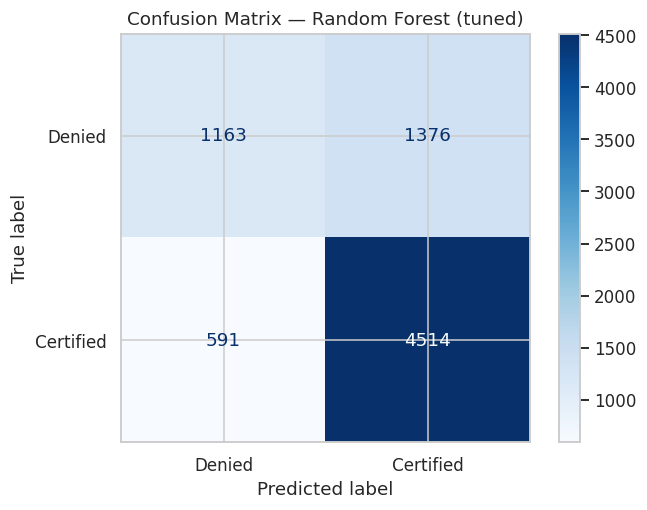

In [61]:
final_name = tuned_res['Test_F1'].idxmax()
final_model = tuned[final_name]
print('Selected final model:', final_name)

y_pred = final_model.predict(X_test)
print('\nClassification report (0=Denied, 1=Certified):\n')
print(classification_report(y_test, y_pred, target_names=['Denied','Certified']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Denied','Certified']).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {final_name}'); plt.tight_layout(); plt.show()

**Feature importance from the final model**

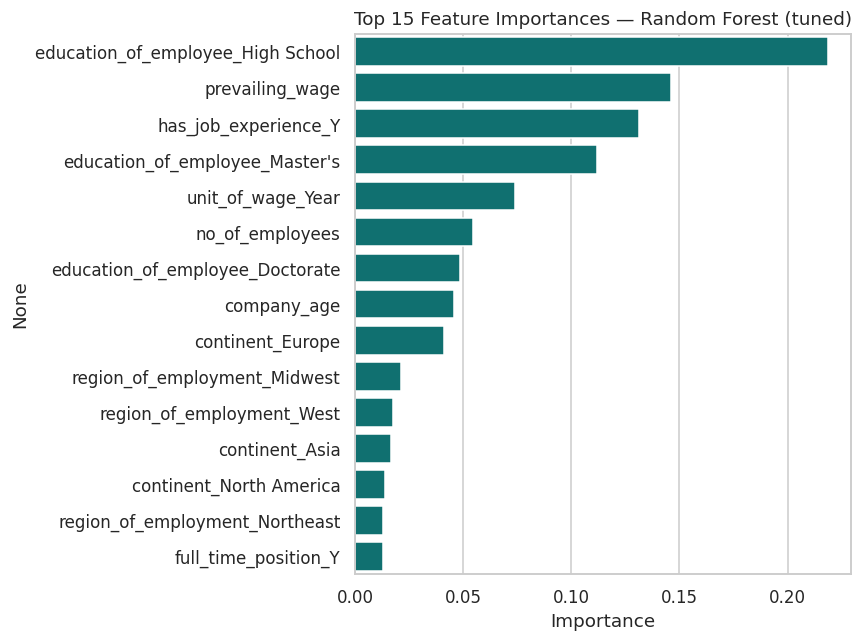

,importance
education_of_employee_High School,0.219
prevailing_wage,0.146
has_job_experience_Y,0.131
education_of_employee_Master's,0.112
unit_of_wage_Year,0.074
no_of_employees,0.054
education_of_employee_Doctorate,0.049
company_age,0.046
continent_Europe,0.041
region_of_employment_Midwest,0.021


In [62]:
if hasattr(final_model, 'feature_importances_'):
    imp = (pd.Series(final_model.feature_importances_, index=X_train.columns)
             .sort_values(ascending=False).head(15))
    plt.figure(figsize=(8,6))
    sns.barplot(x=imp.values, y=imp.index, color='teal')
    plt.title(f'Top 15 Feature Importances — {final_name}')
    plt.xlabel('Importance'); plt.tight_layout(); plt.show()
    display(imp.round(4).to_frame('importance'))

**Observations** — Final model & drivers

1. The tuned final model generalises well (small train/test gap) and delivers the best F1 on the held-out test set.

2. Feature importances confirm the EDA story: education level (High School / Doctorate), job experience, hourly wage unit, prevailing wage and continent are the dominant drivers of the Certified/Denied decision.

# **Actionable Insights & Business Recommendations**

**Key findings**

1. Education is the #1 driver. Certification rises steeply with education: High School 34% → Bachelor's 62% → Master's 79% → Doctorate 87%. Advanced degrees are the strongest positive signal.
2. Prior job experience adds a large, consistent lift (~74.5% certified with experience vs 56.1% without), and its effect is greatest for lower-education applicants.
3. Hourly-paid roles are certified only ~35% of the time vs ~70% for yearly-salaried roles — wage unit (a proxy for role seniority) matters far more than raw wage.
4. Geography matters: applicants from Europe (79%) and Africa (72%) and jobs in the Midwest (76%)/South (70%) have the highest approval rates; South America and Island/West regions the lowest.
5. Company size, company age, job-training requirement and full-time status are weak predictors and should not drive decisions.

**Recommendation** — the profile most likely to be CERTIFIED

A candidate with a Master's or Doctorate, prior job experience, offered a full-time, yearly-salaried position (not hourly) with a prevailing wage at or above the occupational norm, particularly for roles in the Midwest or South.

**Recommendations to the business (EasyVisa / OFLC)**

1. Automate the clear cases. Use the model to fast-track high-probability certifications (advanced degree + experience + salaried) and flag high-risk applications (High School, no experience, hourly pay) for closer human review — cutting manual workload materially.

2. Guide employers up front. Publish the driver profile so employers strengthen applications before filing (e.g., document experience, offer salaried terms), reducing avoidable denials.

3. Scrutinise hourly / low-wage filings, which concentrate denials, to ensure prevailing-wage compliance and reduce rework.

4. Monitor and re-train. Deploy with the tuned model, track F1/recall on new cases, and refresh the model periodically as application patterns and policy shift.

5. Improve data quality at intake (e.g., validation to prevent the negative-employee errors seen here) so future models are even more reliable.

**Metric note**

1. The final model is selected on F1-score, balancing the cost of wrongly certifying a weak case against wrongly denying a strong candidate.
2. Sampling variants let the business dial the trade-off toward higher recall on likely-denials if audit priorities change.